## FORECASTING DAN KLASIFIKASI INTENSITAS CURAH HUJAN DI STASIUN BMKG SELURUH JAWA TIMUR TAHUN 2024

### FORECASTING INTENSITAS HUJAN 7 HARI KE DEPAN DI STASIUN BMKG SELURUH JAWA TIMUR TAHUN 2024 MENGGUNAKAN EXPONENSIAL SMOOTHING

IMPORT LIBRARY

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import plotly.express as px
import plotly.express as px
import ipywidgets as widgets
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xgboost import XGBClassifier
import plotly.graph_objects as go
from IPython.display import display
from pycaret.classification import *
from pycaret.classification import save_model
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from IPython.display import display, clear_output, HTML
from pycaret.time_series import TSForecastingExperiment
from pycaret.classification import load_model, predict_model
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    STATS_MODELS_AVAILABLE = True
except:
    STATS_MODELS_AVAILABLE = False

LOAD DATA

In [2]:
df = pd.read_csv("data_stasiun_new.csv")
print("Data lengkap:")
df

Data lengkap:


,tanggal,stasiun,curah_hujan,suhu,kelembapan,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude
0,2024-01-01,Stasiun Meteorologi Juanda,3.8,29.9,83.0,1.95339,99,0.00000,0.71544,78,-7.372351,112.781699
1,2024-01-01,Stasiun Meteorologi Perak 1,0.6,29.9,78.0,1.37082,89,0.00000,0.55643,79,-7.223151,112.724061
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.2,30.2,77.0,1.40119,87,0.00000,0.55643,79,-7.204321,112.735102
3,2024-01-01,Stasiun Meteorologi Trunojoyo,0.0,27.3,91.0,5.00000,98,0.00519,2.00000,123,-7.039760,113.914000
4,2024-01-01,Stasiun Meteorologi Tuban,0.0,30.1,76.0,2.00000,101,0.03650,1.00000,45,-6.822900,111.991770
...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.9,26.3,89.0,6.00000,86,0.25800,0.00000,90,-7.754870,111.946900
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.8,24.6,84.0,1.00000,36,0.31439,0.00000,90,-7.900800,112.597900
4389,2024-12-31,Stasiun Geofisika Malang,46.5,26.1,86.0,3.00000,21,0.82464,0.00000,90,-8.150000,112.450000
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.0,24.1,86.0,7.00000,94,0.25800,0.00000,90,-7.734860,111.766820


TAMBAH KOLOM TEKANAN UDARA DENGAN DATA DUMMY

In [3]:
mean_tekanan = 1010
std_tekanan = 5

np.random.seed(42)
df['tekanan_udara'] = np.random.normal(loc=mean_tekanan, scale=std_tekanan, size=len(df)).round(2)

if 'kelembapan' in df.columns:
    pos = df.columns.get_loc('kelembapan') + 1
    cols = list(df.columns)
    cols.insert(pos, cols.pop(cols.index('tekanan_udara')))
    df = df[cols]
else:
    print("Kolom 'kelembapan' tidak ditemukan, posisi kolom tidak diubah.")

df.to_csv("data_stasiun_bmkg.csv", index=False)
print("Kolom 'tekanan_udara' berhasil ditambahkan setelah kolom 'kelembapan' dan disimpan.")
df

Kolom 'tekanan_udara' berhasil ditambahkan setelah kolom 'kelembapan' dan disimpan.


,tanggal,stasiun,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude
0,2024-01-01,Stasiun Meteorologi Juanda,3.8,29.9,83.0,1012.48,1.95339,99,0.00000,0.71544,78,-7.372351,112.781699
1,2024-01-01,Stasiun Meteorologi Perak 1,0.6,29.9,78.0,1009.31,1.37082,89,0.00000,0.55643,79,-7.223151,112.724061
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.2,30.2,77.0,1013.24,1.40119,87,0.00000,0.55643,79,-7.204321,112.735102
3,2024-01-01,Stasiun Meteorologi Trunojoyo,0.0,27.3,91.0,1017.62,5.00000,98,0.00519,2.00000,123,-7.039760,113.914000
4,2024-01-01,Stasiun Meteorologi Tuban,0.0,30.1,76.0,1008.83,2.00000,101,0.03650,1.00000,45,-6.822900,111.991770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.9,26.3,89.0,1002.84,6.00000,86,0.25800,0.00000,90,-7.754870,111.946900
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.8,24.6,84.0,1010.73,1.00000,36,0.31439,0.00000,90,-7.900800,112.597900
4389,2024-12-31,Stasiun Geofisika Malang,46.5,26.1,86.0,1012.93,3.00000,21,0.82464,0.00000,90,-8.150000,112.450000
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.0,24.1,86.0,1012.57,7.00000,94,0.25800,0.00000,90,-7.734860,111.766820


STRUKTUR DAN EKSPLORASI DATA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4392 entries, 0 to 4391
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tanggal               4392 non-null   object 
 1   stasiun               4392 non-null   object 
 2   curah_hujan           3989 non-null   float64
 3   suhu                  4340 non-null   float64
 4   kelembapan            4359 non-null   float64
 5   tekanan_udara         4392 non-null   float64
 6   kecepatan_angin       4392 non-null   float64
 7   arah_angin            4392 non-null   int64  
 8   gelombang_signifikan  4392 non-null   float64
 9   arus_laut             4392 non-null   float64
 10  arah_arus_laut        4392 non-null   int64  
 11  latitude              4392 non-null   float64
 12  longitude             4392 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 446.2+ KB


CEK MISSING VALUE

In [5]:
missing = df.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\nTidak ada data kosong.")
else:
    print(f"Ditemukan {missing.sum()} data kosong. Perlu dibersihkan sebelum modelling.")

tanggal                   0
stasiun                   0
curah_hujan             403
suhu                     52
kelembapan               33
tekanan_udara             0
kecepatan_angin           0
arah_angin                0
gelombang_signifikan      0
arus_laut                 0
arah_arus_laut            0
latitude                  0
longitude                 0
dtype: int64
Ditemukan 488 data kosong. Perlu dibersihkan sebelum modelling.


MENGISI NILAI KOSONG

In [6]:
df = df.copy()
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].replace([0, np.inf, -np.inf], np.nan)
means = df[num_cols].mean()
df[num_cols] = df[num_cols].fillna(means)
print(df.isnull().sum())

tanggal                 0
stasiun                 0
curah_hujan             0
suhu                    0
kelembapan              0
tekanan_udara           0
kecepatan_angin         0
arah_angin              0
gelombang_signifikan    0
arus_laut               0
arah_arus_laut          0
latitude                0
longitude               0
dtype: int64


CEK DATA DUPLIKAT

In [7]:
if {'stasiun', 'tanggal'}.issubset(df.columns):
    duplikat = df.duplicated(subset=['stasiun', 'tanggal']).sum()
else:
    duplikat = df.duplicated().sum()
print("=== Pemeriksaan Data Duplikat ===")
print(f"Jumlah data duplikat: {duplikat}")

if duplikat > 0:
    print("Data mengandung duplikat. Disarankan untuk menghapusnya dengan perintah berikut:")
    print("df = df.drop_duplicates()")
else:
    print("Tidak ada data duplikat yang ditemukan.")

=== Pemeriksaan Data Duplikat ===
Jumlah data duplikat: 0
Tidak ada data duplikat yang ditemukan.


CEK KONSISTENSI DATA GEOSPASIAL

In [8]:
if 'latitude' in df.columns and 'longitude' in df.columns:
    print("=== Pemeriksaan Konsistensi Data Geospasial ===")

    lat_min, lat_max = df['latitude'].min(), df['latitude'].max()
    lon_min, lon_max = df['longitude'].min(), df['longitude'].max()

    print(f"Latitude  : {lat_min:.4f} – {lat_max:.4f}")
    print(f"Longitude : {lon_min:.4f} – {lon_max:.4f}")

    invalid_coords = df[
        (df['latitude'] < -90) | (df['latitude'] > 90) |
        (df['longitude'] < -180) | (df['longitude'] > 180)
    ]

    if invalid_coords.empty:
        print("Semua koordinat valid.")
    else:
        print(f"Ditemukan {len(invalid_coords)} koordinat tidak valid:")
        display(invalid_coords)
else:
    print("Kolom 'latitude' dan/atau 'longitude' tidak ditemukan dalam dataset.")

=== Pemeriksaan Konsistensi Data Geospasial ===
Latitude  : -8.2148 – -5.8511
Longitude : 111.7668 – 114.3553
Semua koordinat valid.


CEK STATISTIK DESKRIPTIF DAN KORELASI

=== Statistik Deskriptif Kolom Numerik ===


,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude
count,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00
mean,13.95,27.51,77.54,1010.04,4.11,241.94,0.22,9.17,119.65,-7.41,112.72
std,14.51,2.32,7.74,4.99,1.57,63.54,0.11,25.72,65.61,0.63,0.72
min,0.10,19.30,47.00,993.79,0.17,1.00,0.00,0.20,2.00,-8.21,111.77
25%,8.38,26.20,72.00,1006.73,4.11,270.00,0.22,4.00,90.00,-7.79,112.34
50%,13.95,28.10,77.54,1010.06,4.11,270.00,0.22,9.17,90.00,-7.51,112.67
75%,13.95,29.10,83.00,1013.31,4.11,270.00,0.22,9.17,122.00,-7.16,112.75
max,243.90,32.10,99.00,1029.63,19.00,359.00,1.18,818.00,359.00,-5.85,114.36


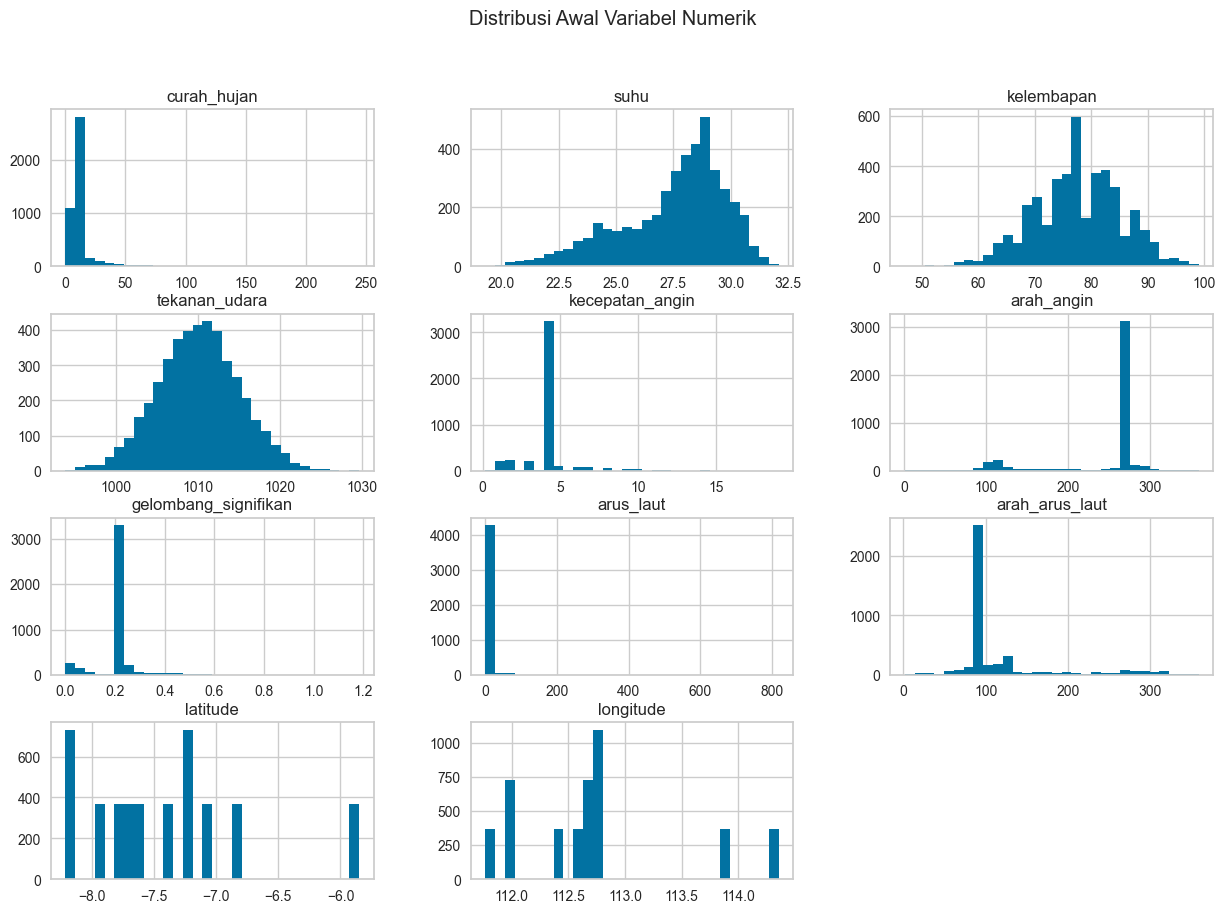

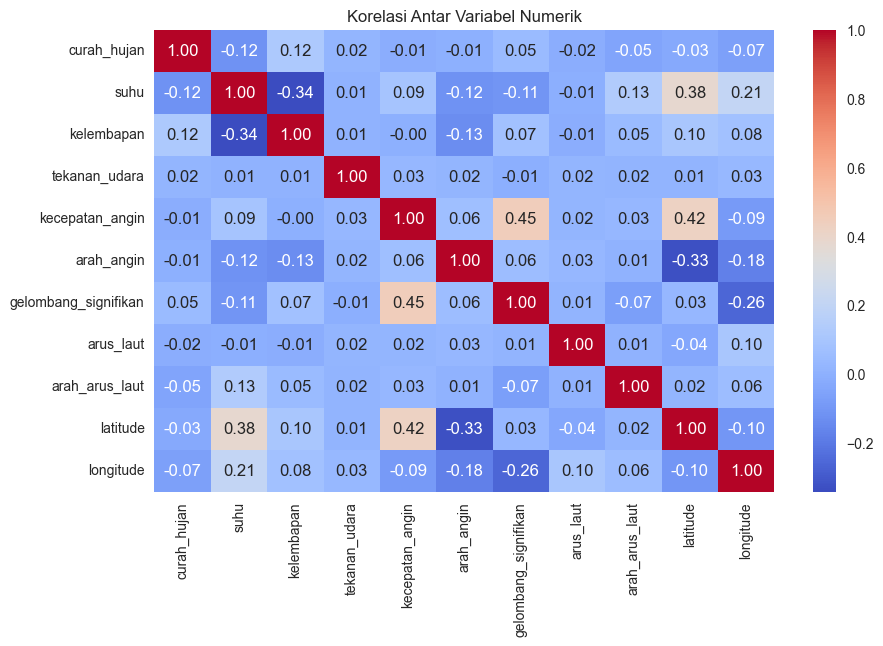

In [9]:
def eda_numerik(df, bins=30, figsize_hist=(15,10), figsize_corr=(10,6), cmap="coolwarm"):
    numeric_cols = df.select_dtypes(include='number').columns
    if len(numeric_cols) == 0:
        print("Tidak ada kolom numerik untuk dianalisis.")
        return
    
    print("=== Statistik Deskriptif Kolom Numerik ===")
    display(df[numeric_cols].describe().round(2))
    
    df[numeric_cols].hist(bins=bins, figsize=figsize_hist)
    plt.suptitle("Distribusi Awal Variabel Numerik")
    plt.show()
    
    corr_matrix = df[numeric_cols].corr()
    plt.figure(figsize=figsize_corr)
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap)
    plt.title("Korelasi Antar Variabel Numerik")
    plt.show()
    
    return corr_matrix

corr_matrix = eda_numerik(df)

VISUALISASI TREN WAKTU

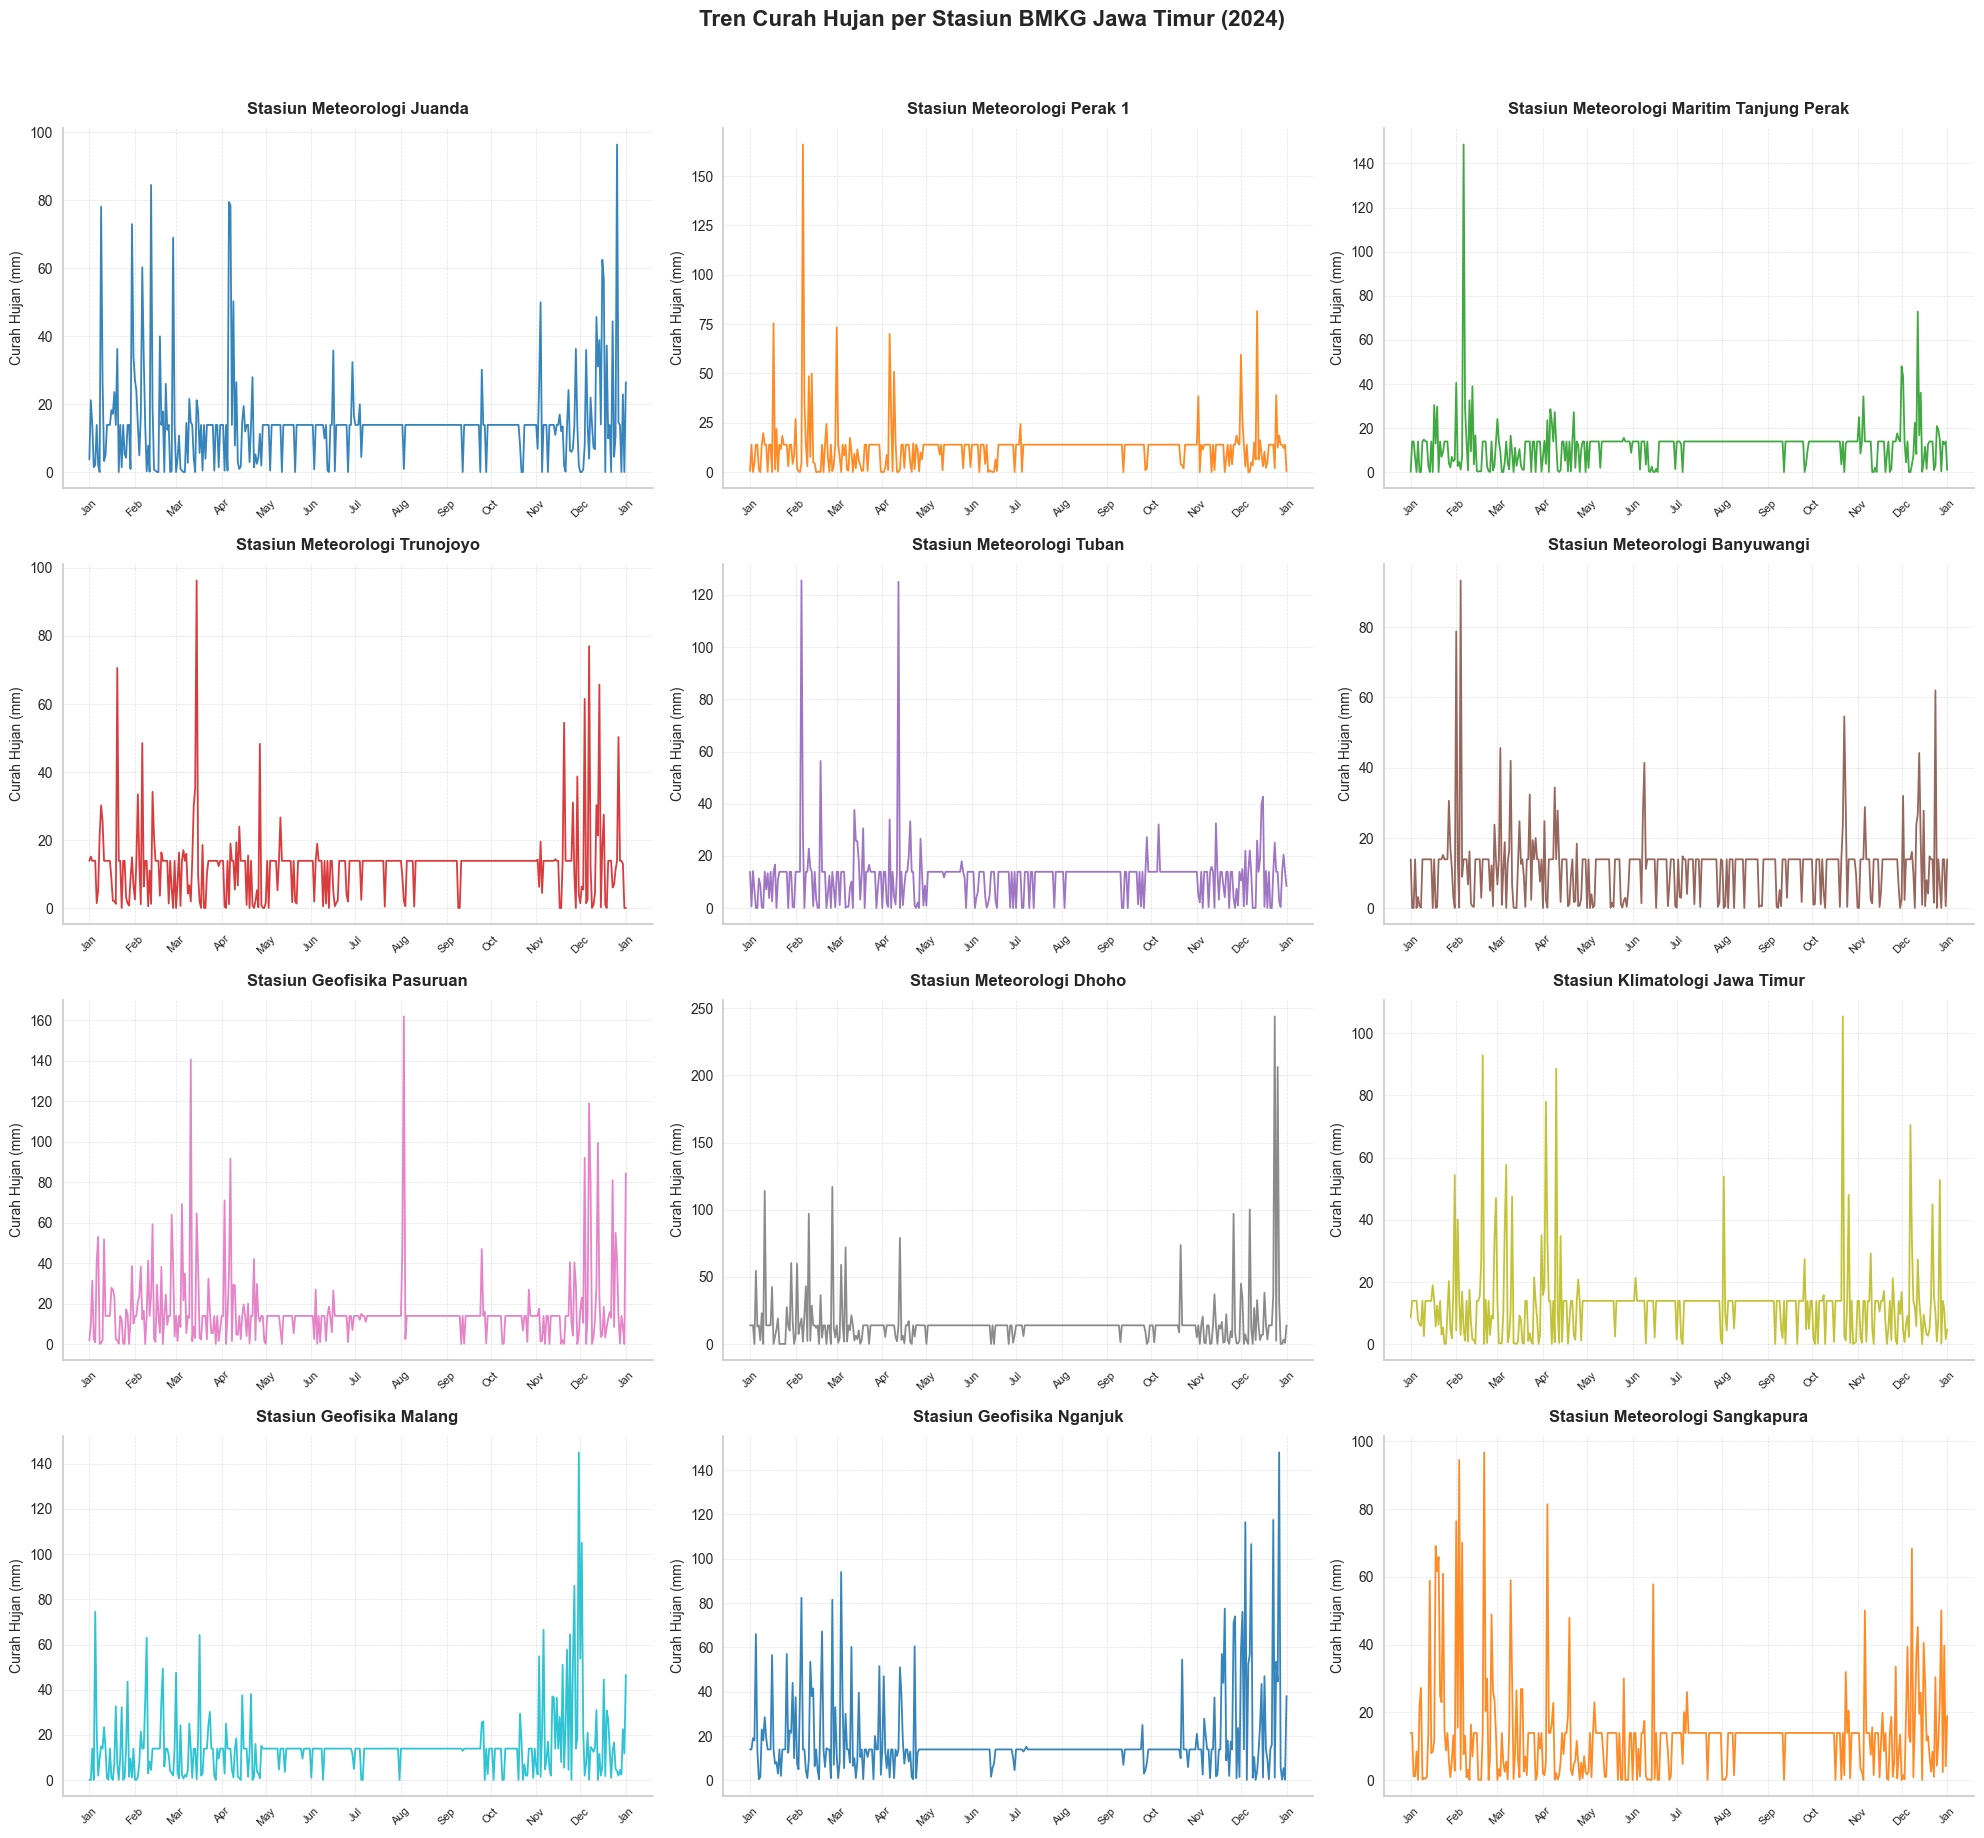

In [10]:
stasiun_list = df['stasiun'].unique().tolist()

n_cols = 3
n_rows = 4

plt.figure(figsize=(20, 18))
palette = sns.color_palette("tab10", n_colors=len(stasiun_list))

for i, stasiun in enumerate(stasiun_list):
    subset = df[df['stasiun'] == stasiun].copy()

    if 'tanggal' not in subset.columns:
        print(f"Kolom 'tanggal' hilang pada stasiun: {stasiun}")
        continue

    if subset['tanggal'].isna().all():
        print(f"Tanggal tidak valid di stasiun: {stasiun}")
        continue

    ax = plt.subplot(n_rows, n_cols, i+1)

    sns.lineplot(
        data=subset,
        x='tanggal',
        y='curah_hujan',
        linewidth=1.3,
        alpha=0.9,
        color=palette[i % 10],
        ax=ax
    )

    ax.set_title(stasiun, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Curah Hujan (mm)", fontsize=10)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=8)

    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    sns.despine(ax=ax)

plt.suptitle("Tren Curah Hujan per Stasiun BMKG Jawa Timur (2024)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


JALANKAN MODEL UNTUK ROLLING-PER-ROW-GROUP

In [11]:
MIN_HISTORY = 6
MAX_HISTORY = 365
df["forecast_1"] = np.nan
df["forecast_2"] = np.nan
df["forecast_3"] = np.nan
df["forecast_4"] = np.nan
df["forecast_5"] = np.nan
df["forecast_6"] = np.nan
df["forecast_7"] = np.nan

groups = df["stasiun"].fillna("__nan__").unique().tolist() if "stasiun" in df.columns else [None]

for g in groups:
    if g is None:
        sub = df.copy()
        idxs = df.index.tolist()
    else:
        sub = df[df["stasiun"].fillna("__nan__") == g]
        idxs = sub.index.tolist()

    if "tanggal" in sub.columns:
        sub = sub.sort_values("tanggal")
        idxs = sub.index.tolist()

    values = sub["curah_hujan"].values

    for pos, idx in enumerate(tqdm(idxs, desc=f"Forecasting {g}")):
        start_pos = max(0, pos - MAX_HISTORY + 1)
        history = values[start_pos:pos+1]
        history_valid = history[~np.isnan(history)]

        if len(history_valid) < MIN_HISTORY:
            if len(history_valid) == 0:
                forecasts = [np.nan]*7
            else:
                last = float(history_valid[-1])
                forecasts = [last]*7
        else:
            try:
                model = ExponentialSmoothing(
                    history_valid,
                    trend="add",              
                    seasonal="add",            
                    seasonal_periods=7         
                ).fit(optimized=True)

                f = model.forecast(7)
                forecasts = [float(x) for x in f]
            except:
                last = float(history_valid[-1])
                forecasts = [last]*7

        for i in range(1, 8):
            df.at[idx, f"forecast_{i}"] = forecasts[i-1]

Forecasting Stasiun Meteorologi Perak 1: 100%|██████████| 366/366 [01:10<00:00,  5.17it/s]
Forecasting Stasiun Meteorologi Maritim Tanjung Perak: 100%|██████████| 366/366 [01:41<00:00,  3.61it/s]
Forecasting Stasiun Meteorologi Sangkapura: 100%|██████████| 366/366 [00:39<00:00,  9.32it/s]


EVALUASI MODEL

In [12]:
def safe_mape(y_true, y_pred):
    y_true_safe = y_true.copy()
    y_true_safe = y_true_safe.replace(0, y_true_safe[y_true_safe != 0].min())
    return (abs((y_true_safe - y_pred) / y_true_safe).mean()) * 100

def smape(y_true, y_pred):
    denom = (abs(y_true) + abs(y_pred)) / 2
    denom = denom.replace(0, denom[denom != 0].min())
    return (abs(y_true - y_pred) / denom).mean() * 100


results = []
for i in range(1, 8):
    y_true = df["curah_hujan"]
    y_pred = df[f"forecast_{i}"]
    mask = (~y_true.isna()) & (~y_pred.isna())
    y_true, y_pred = y_true[mask], y_pred[mask]

    results.append({
        'Horizon': f'H+{i}',
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'R²': r2_score(y_true, y_pred),
        'MAPE (%)': safe_mape(y_true, y_pred),
        'SMAPE (%)': smape(y_true, y_pred)
    })

eval_df = pd.DataFrame(results)

mean_df = pd.DataFrame({
    'Horizon': ['Rata-rata'],
    'MAE': [eval_df['MAE'].mean()],
    'RMSE': [eval_df['RMSE'].mean()],
    'R²': [eval_df['R²'].mean()],
    'MAPE (%)': [eval_df['MAPE (%)'].mean()],
    'SMAPE (%)': [eval_df['SMAPE (%)'].mean()]
})


if "stasiun" in df.columns:
    station_list = []
    for s in df["stasiun"].unique():
        subset = df[df["stasiun"] == s]
        for i in range(1, 8):
            y_true = subset["curah_hujan"]
            y_pred = subset[f"forecast_{i}"]
            mask = (~y_true.isna()) & (~y_pred.isna())
            y_true, y_pred = y_true[mask], y_pred[mask]

            if len(y_true) > 0:
                station_list.append({
                    'Stasiun': s,
                    'Horizon': f'H+{i}',
                    'MAE': mean_absolute_error(y_true, y_pred),
                    'RMSE': mean_squared_error(y_true, y_pred, squared=False),
                    'R²': r2_score(y_true, y_pred),
                    'MAPE (%)': safe_mape(y_true, y_pred),
                    'SMAPE (%)': smape(y_true, y_pred)
                })
    station_df = pd.DataFrame(station_list)
else:
    station_df = pd.DataFrame()


print("=== HASIL EVALUASI FORECASTING 7 HARI ===")
display(eval_df)

print("=== EVALUASI RATA-RATA ===")
display(mean_df)

print("=== EVALUASI PER STASIUN ===")
display(station_df)

=== HASIL EVALUASI FORECASTING 7 HARI ===


,Horizon,MAE,RMSE,R²,MAPE (%),SMAPE (%)
0,H+1,7.612453,13.970456,0.072153,1022.641490,59.775991
1,H+2,7.718535,14.250477,0.034585,1065.147446,59.953734
2,H+3,7.633212,14.070246,0.058851,1044.868334,59.661364
3,H+4,7.703458,14.184465,0.043509,1047.598822,59.786250
4,H+5,7.654126,14.147242,0.048522,1028.998969,59.582491
5,H+6,7.705382,14.239377,0.036088,1048.635524,59.643668
6,H+7,7.207242,13.192900,0.172562,972.409783,58.096985


=== EVALUASI RATA-RATA ===


,Horizon,MAE,RMSE,R²,MAPE (%),SMAPE (%)
0,Rata-rata,7.604915,14.00788,0.06661,1032.900053,59.500069


=== EVALUASI PER STASIUN ===


,Stasiun,Horizon,MAE,RMSE,R²,MAPE (%),SMAPE (%)
0,Stasiun Meteorologi Juanda,H+1,7.739490,13.083149,-0.014985,1179.228659,58.354412
1,Stasiun Meteorologi Juanda,H+2,7.780314,13.625442,-0.100870,1274.777470,57.811201
2,Stasiun Meteorologi Juanda,H+3,7.493304,13.093100,-0.016529,1221.485065,56.671055
3,Stasiun Meteorologi Juanda,H+4,7.727463,13.174734,-0.029245,1259.182418,57.791536
4,Stasiun Meteorologi Juanda,H+5,7.736588,13.391667,-0.063418,1180.272858,57.984989
...,...,...,...,...,...,...,...
79,Stasiun Meteorologi Sangkapura,H+3,8.796703,13.519263,0.095304,1089.602738,75.494161
80,Stasiun Meteorologi Sangkapura,H+4,9.101747,13.962559,0.035001,1073.351656,77.076527
81,Stasiun Meteorologi Sangkapura,H+5,8.889331,13.638653,0.079255,1106.295591,75.241335
82,Stasiun Meteorologi Sangkapura,H+6,9.330421,14.246410,-0.004633,1048.065033,78.333932


SAVE DATA

In [13]:
rename_dict = {}
for i in range(1, 8):
    rename_dict[f"forecast_{i}"] = f"forecast_num_{i}"
    rename_dict[f"forecast_num_{i}"] = f"forecast_{i}"

df = df.rename(columns=rename_dict)

ordered_columns = [
    'tanggal', 'stasiun', 'curah_hujan', 'suhu', 'kelembapan', 'tekanan_udara',
    'kecepatan_angin', 'arah_angin', 'gelombang_signifikan', 'arus_laut',
    'arah_arus_laut', 'latitude', 'longitude', 'intensitas_hujan'
]

for i in range(1, 8):
    ordered_columns.append(f'forecast_{i}')
for i in range(1, 8):
    ordered_columns.append(f'forecast_num_{i}')

df = df[[col for col in ordered_columns if col in df.columns]]
df.to_csv("hasil_forecast_curah_hujan_exponensmooth.csv", index=False)
df


,tanggal,stasiun,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude,forecast_num_1,forecast_num_2,forecast_num_3,forecast_num_4,forecast_num_5,forecast_num_6,forecast_num_7
0,2024-01-01,Stasiun Meteorologi Juanda,3.800000,29.9,83.0,1012.48,1.95339,99.0,0.221878,0.715440,78.0,-7.372351,112.781699,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000
1,2024-01-01,Stasiun Meteorologi Perak 1,0.600000,29.9,78.0,1009.31,1.37082,89.0,0.221878,0.556430,79.0,-7.223151,112.724061,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.200000,30.2,77.0,1013.24,1.40119,87.0,0.221878,0.556430,79.0,-7.204321,112.735102,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000
3,2024-01-01,Stasiun Meteorologi Trunojoyo,13.947431,27.3,91.0,1017.62,5.00000,98.0,0.005190,2.000000,123.0,-7.039760,113.914000,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431
4,2024-01-01,Stasiun Meteorologi Tuban,13.947431,30.1,76.0,1008.83,2.00000,101.0,0.036500,1.000000,45.0,-6.822900,111.991770,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.900000,26.3,89.0,1002.84,6.00000,86.0,0.258000,9.169743,90.0,-7.754870,111.946900,39.115075,28.511059,32.241924,28.727822,33.010769,47.025786,30.213962
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.800000,24.6,84.0,1010.73,1.00000,36.0,0.314390,9.169743,90.0,-7.900800,112.597900,12.202776,11.097678,13.494423,12.226543,11.471195,13.508720,13.175945
4389,2024-12-31,Stasiun Geofisika Malang,46.500000,26.1,86.0,1012.93,3.00000,21.0,0.824640,9.169743,90.0,-8.150000,112.450000,14.325843,14.785821,17.763987,17.621513,15.351013,16.859453,16.683590
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.000000,24.1,86.0,1012.57,7.00000,94.0,0.258000,9.169743,90.0,-7.734860,111.766820,29.525251,33.617842,32.938239,32.490023,37.993776,38.160562,39.441362


### KLASIFIKASI INTENSITAS CURAH HUJAN DI STASIUN BMKG SELURUH JAWA TIMUR TAHUN 2024

LOAD DATASET

In [14]:
data = pd.read_csv("hasil_forecast_curah_hujan_exponensmooth.csv")
print("Data lengkap:")
data

Data lengkap:


,tanggal,stasiun,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude,forecast_num_1,forecast_num_2,forecast_num_3,forecast_num_4,forecast_num_5,forecast_num_6,forecast_num_7
0,2024-01-01,Stasiun Meteorologi Juanda,3.800000,29.9,83.0,1012.48,1.95339,99.0,0.221878,0.715440,78.0,-7.372351,112.781699,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000
1,2024-01-01,Stasiun Meteorologi Perak 1,0.600000,29.9,78.0,1009.31,1.37082,89.0,0.221878,0.556430,79.0,-7.223151,112.724061,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.200000,30.2,77.0,1013.24,1.40119,87.0,0.221878,0.556430,79.0,-7.204321,112.735102,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000
3,2024-01-01,Stasiun Meteorologi Trunojoyo,13.947431,27.3,91.0,1017.62,5.00000,98.0,0.005190,2.000000,123.0,-7.039760,113.914000,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431
4,2024-01-01,Stasiun Meteorologi Tuban,13.947431,30.1,76.0,1008.83,2.00000,101.0,0.036500,1.000000,45.0,-6.822900,111.991770,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.900000,26.3,89.0,1002.84,6.00000,86.0,0.258000,9.169743,90.0,-7.754870,111.946900,39.115075,28.511059,32.241924,28.727822,33.010769,47.025786,30.213962
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.800000,24.6,84.0,1010.73,1.00000,36.0,0.314390,9.169743,90.0,-7.900800,112.597900,12.202776,11.097678,13.494423,12.226543,11.471195,13.508720,13.175945
4389,2024-12-31,Stasiun Geofisika Malang,46.500000,26.1,86.0,1012.93,3.00000,21.0,0.824640,9.169743,90.0,-8.150000,112.450000,14.325843,14.785821,17.763987,17.621513,15.351013,16.859453,16.683590
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.000000,24.1,86.0,1012.57,7.00000,94.0,0.258000,9.169743,90.0,-7.734860,111.766820,29.525251,33.617842,32.938239,32.490023,37.993776,38.160562,39.441362


CEK STRUKTUR DATA, NILAI HILANG, DAN DUPLIKAT

In [15]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

print("=== STRUKTUR DATASET ===")
display(data.dtypes.to_frame('Tipe Data'))

print(f"\nJumlah Baris: {data.shape[0]} | Jumlah Kolom: {data.shape[1]}")

print("\n=== CEK NILAI HILANG (MISSING VALUES) ===")
missing_data = pd.DataFrame({
    'Jumlah Missing': data.isna().sum(),
    'Persentase (%)': (data.isna().sum() / len(data) * 100).round(2)
})
display(missing_data)

print("\n=== CEK DATA DUPLIKAT ===")
dup_count = data.duplicated().sum()
print(f"Jumlah data duplikat: {dup_count}")

=== STRUKTUR DATASET ===


,Tipe Data
tanggal,object
stasiun,object
curah_hujan,float64
suhu,float64
kelembapan,float64
tekanan_udara,float64
kecepatan_angin,float64
arah_angin,float64
gelombang_signifikan,float64
arus_laut,float64



Jumlah Baris: 4392 | Jumlah Kolom: 20

=== CEK NILAI HILANG (MISSING VALUES) ===


,Jumlah Missing,Persentase (%)
tanggal,0,0.0
stasiun,0,0.0
curah_hujan,0,0.0
suhu,0,0.0
kelembapan,0,0.0
tekanan_udara,0,0.0
kecepatan_angin,0,0.0
arah_angin,0,0.0
gelombang_signifikan,0,0.0
arus_laut,0,0.0



=== CEK DATA DUPLIKAT ===
Jumlah data duplikat: 0


CEK STATISTIK DESKRIPTIF DAN KORELASI

=== Statistik Deskriptif Kolom Numerik ===


,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude,forecast_num_1,forecast_num_2,forecast_num_3,forecast_num_4,forecast_num_5,forecast_num_6,forecast_num_7
count,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00
mean,13.95,27.51,77.54,1010.04,4.11,241.94,0.22,9.17,119.65,-7.41,112.72,13.69,13.73,13.75,13.77,13.78,13.79,13.80
std,14.51,2.32,7.74,4.99,1.57,63.54,0.11,25.72,65.61,0.63,0.72,7.12,7.32,7.44,7.49,7.65,7.85,8.20
min,0.10,19.30,47.00,993.79,0.17,1.00,0.00,0.20,2.00,-8.21,111.77,-8.47,-8.76,-12.93,-8.45,-9.49,-11.21,-6.48
25%,8.38,26.20,72.00,1006.73,4.11,270.00,0.22,4.00,90.00,-7.79,112.34,10.46,10.45,10.47,10.49,10.49,10.49,10.44
50%,13.95,28.10,77.54,1010.06,4.11,270.00,0.22,9.17,90.00,-7.51,112.67,12.42,12.40,12.42,12.42,12.43,12.43,12.42
75%,13.95,29.10,83.00,1013.31,4.11,270.00,0.22,9.17,122.00,-7.16,112.75,15.09,15.12,15.10,15.09,15.11,15.03,15.04
max,243.90,32.10,99.00,1029.63,19.00,359.00,1.18,818.00,359.00,-5.85,114.36,114.00,121.21,150.83,169.09,193.38,219.97,265.25


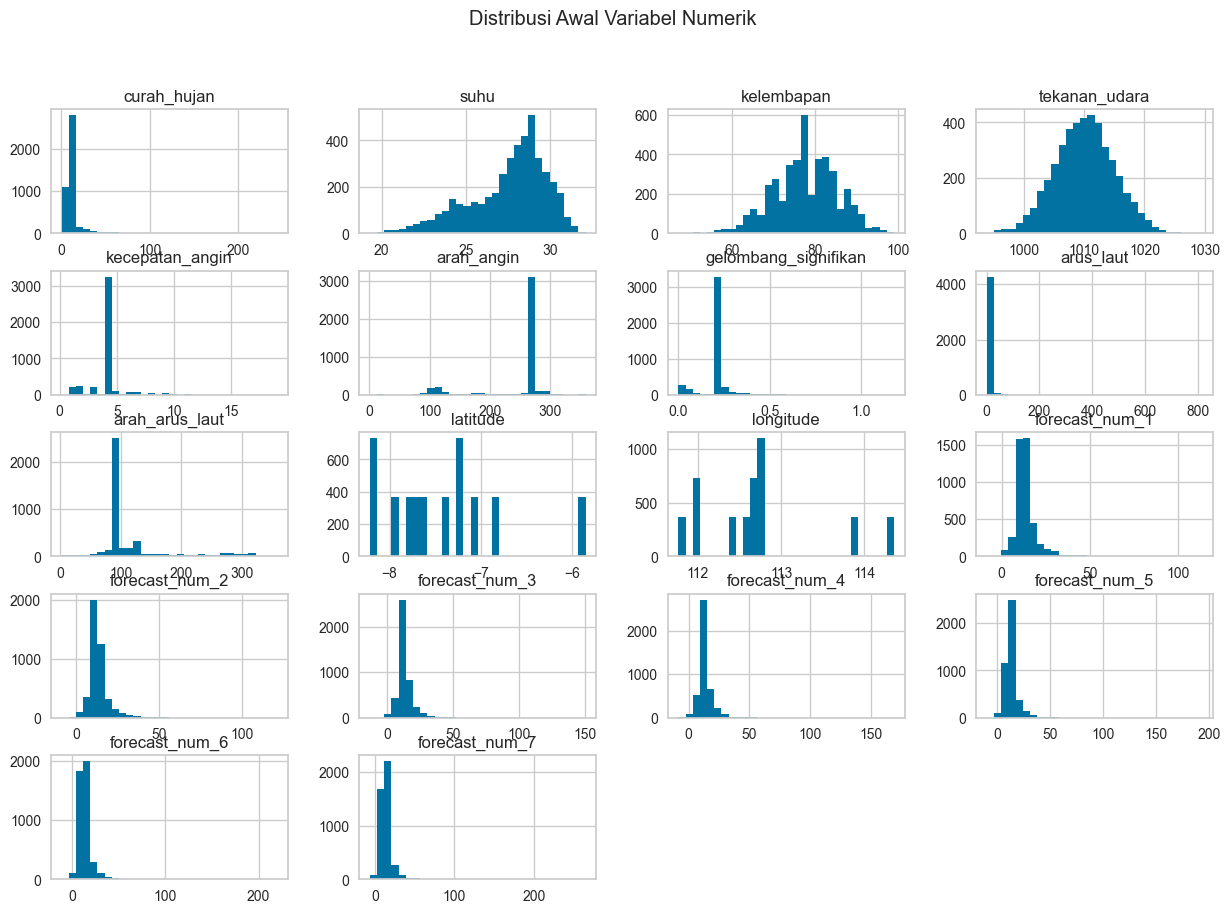

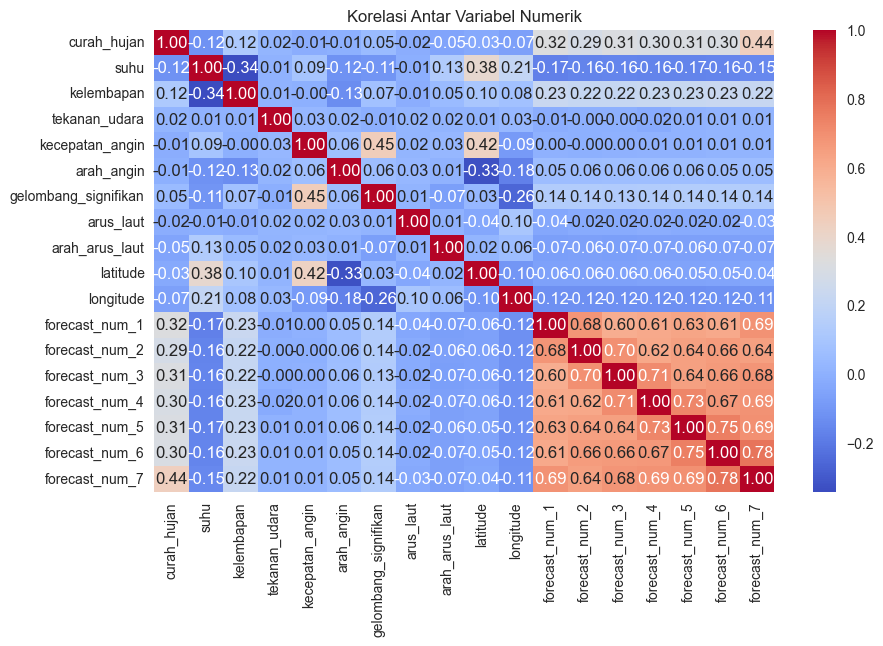

In [16]:
def eda_numerik(data, bins=30, figsize_hist=(15,10), figsize_corr=(10,6), cmap="coolwarm"):
    numeric_cols = data.select_dtypes(include='number').columns
    if len(numeric_cols) == 0:
        print("Tidak ada kolom numerik untuk dianalisis.")
        return
    
    print("=== Statistik Deskriptif Kolom Numerik ===")
    display(data[numeric_cols].describe().round(2))
    
    data[numeric_cols].hist(bins=bins, figsize=figsize_hist)
    plt.suptitle("Distribusi Awal Variabel Numerik")
    plt.show()
    
    corr_matrix = data[numeric_cols].corr()
    plt.figure(figsize=figsize_corr)
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap)
    plt.title("Korelasi Antar Variabel Numerik")
    plt.show()
    
    return corr_matrix

corr_matrix = eda_numerik(data)


KLASIFIKASI BERDASARKAN CURAH HUJAN (mm)

In [17]:
def klasifikasi_hujan(ch):
    if ch <= 4:
        return "Tidak Hujan"
    elif ch <= 20:
        return "Ringan"
    elif ch <= 50:
        return "Sedang"
    elif ch <= 100:
        return "Lebat"
    else:
        return "Sangat Lebat"

data["intensitas_hujan"] = data["curah_hujan"].apply(klasifikasi_hujan)

for i in range(1, 8):
    kolom_forecast = f"forecast_num_{i}"
    kolom_intensitas = f"intensitas_forecast_{i}"
    if kolom_forecast in data.columns:
        data[kolom_intensitas] = data[kolom_forecast].apply(klasifikasi_hujan)

print("Variabel 'intensitas_hujan' dan 'intensitas_forecast_1-7' berhasil ditambahkan:")
display(data)

Variabel 'intensitas_hujan' dan 'intensitas_forecast_1-7' berhasil ditambahkan:


,tanggal,stasiun,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude,forecast_num_1,forecast_num_2,forecast_num_3,forecast_num_4,forecast_num_5,forecast_num_6,forecast_num_7,intensitas_hujan,intensitas_forecast_1,intensitas_forecast_2,intensitas_forecast_3,intensitas_forecast_4,intensitas_forecast_5,intensitas_forecast_6,intensitas_forecast_7
0,2024-01-01,Stasiun Meteorologi Juanda,3.800000,29.9,83.0,1012.48,1.95339,99.0,0.221878,0.715440,78.0,-7.372351,112.781699,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
1,2024-01-01,Stasiun Meteorologi Perak 1,0.600000,29.9,78.0,1009.31,1.37082,89.0,0.221878,0.556430,79.0,-7.223151,112.724061,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.200000,30.2,77.0,1013.24,1.40119,87.0,0.221878,0.556430,79.0,-7.204321,112.735102,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
3,2024-01-01,Stasiun Meteorologi Trunojoyo,13.947431,27.3,91.0,1017.62,5.00000,98.0,0.005190,2.000000,123.0,-7.039760,113.914000,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
4,2024-01-01,Stasiun Meteorologi Tuban,13.947431,30.1,76.0,1008.83,2.00000,101.0,0.036500,1.000000,45.0,-6.822900,111.991770,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.900000,26.3,89.0,1002.84,6.00000,86.0,0.258000,9.169743,90.0,-7.754870,111.946900,39.115075,28.511059,32.241924,28.727822,33.010769,47.025786,30.213962,Ringan,Sedang,Sedang,Sedang,Sedang,Sedang,Sedang,Sedang
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.800000,24.6,84.0,1010.73,1.00000,36.0,0.314390,9.169743,90.0,-7.900800,112.597900,12.202776,11.097678,13.494423,12.226543,11.471195,13.508720,13.175945,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
4389,2024-12-31,Stasiun Geofisika Malang,46.500000,26.1,86.0,1012.93,3.00000,21.0,0.824640,9.169743,90.0,-8.150000,112.450000,14.325843,14.785821,17.763987,17.621513,15.351013,16.859453,16.683590,Sedang,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.000000,24.1,86.0,1012.57,7.00000,94.0,0.258000,9.169743,90.0,-7.734860,111.766820,29.525251,33.617842,32.938239,32.490023,37.993776,38.160562,39.441362,Sedang,Sedang,Sedang,Sedang,Sedang,Sedang,Sedang,Sedang


SETUP PYCARET UNTUK PERMODELAN BEST PARAMETER

In [18]:
clf_setup = setup(
    data=data,
    target='intensitas_hujan',
    normalize=True,
    session_id=123,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    train_size=0.8,
    verbose=False
)

print("Setup selesai. Model siap dibandingkan dan dilatih.")


Setup selesai. Model siap dibandingkan dan dilatih.


BANDINGKAN BEBERAPA MODEL

In [19]:
best_models = compare_models(sort='Accuracy', n_select=5)

print("5 Model Terbaik Berdasarkan Akurasi:")
best_models

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.9989,0.0000,0.9989,0.9988,0.9988,0.9975,0.9975,0.1580
gbc,Gradient Boosting Classifier,0.9989,0.0000,0.9989,0.9988,0.9988,0.9975,0.9975,2.3600
xgboost,Extreme Gradient Boosting,0.9989,0.0000,0.9989,0.9988,0.9988,0.9975,0.9975,0.8030
catboost,CatBoost Classifier,0.9989,0.0000,0.9989,0.9988,0.9988,0.9975,0.9975,16.5470
lr,Logistic Regression,0.9638,0.0000,0.9638,0.9623,0.9623,0.9197,0.9201,1.2270
rf,Random Forest Classifier,0.9582,0.0000,0.9582,0.9506,0.9513,0.9031,0.9054,0.6060
lda,Linear Discriminant Analysis,0.9562,0.0000,0.9562,0.9587,0.9560,0.9040,0.9050,0.2120
lightgbm,Light Gradient Boosting Machine,0.9345,0.0000,0.9345,0.9260,0.9238,0.8218,0.8243,0.5520
ada,Ada Boost Classifier,0.9109,0.0000,0.9109,0.8318,0.8690,0.7736,0.7974,0.4370
et,Extra Trees Classifier,0.8918,0.0000,0.8918,0.8874,0.8834,0.7375,0.7479,0.3870


5 Model Terbaik Berdasarkan Akurasi:


[DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                        max_depth=None, max_features=None, max_leaf_nodes=None,
                        min_impurity_decrease=0.0, min_samples_leaf=1,
                        min_samples_split=2, min_weight_fraction_leaf=0.0,
                        monotonic_cst=None, random_state=123, splitter='best'),
 GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                            learning_rate=0.1, loss='log_loss', max_depth=3,
                            max_features=None, max_leaf_nodes=None,
                            min_impurity_decrease=0.0, min_samples_leaf=1,
                            min_samples_split=2, min_weight_fraction_leaf=0.0,
                            n_estimators=100, n_iter_no_change=None,
                            random_state=123, subsample=1.0, tol=0.0001,
                            validation_fraction=0.1, verbose=0,
                            warm_

PILIH DAN LATIH DECISSION TREE CLASSIFIER

In [20]:
dt_model = create_model('dt')
tuned_dt = tune_model(dt_model)
final_dt = finalize_model(tuned_dt)

print("Model Decision Tree sudah dilatih dan difinalisasi.")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9972,0.0000,0.9972,0.9972,0.9971,0.9937,0.9937
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9972,0.0000,0.9972,0.9973,0.9971,0.9937,0.9937
5,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
6,0.9972,0.0000,0.9972,0.9986,0.9975,0.9937,0.9937
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9972,0.0000,0.9972,0.9972,0.9971,0.9937,0.9937
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9972,0.0000,0.9972,0.9973,0.9971,0.9937,0.9937
5,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
6,0.9972,0.0000,0.9972,0.9986,0.9975,0.9937,0.9937
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Model Decision Tree sudah dilatih dan difinalisasi.


EVALUASI MODEL DECISSION TREE CLASSIFIER

In [21]:
evaluate_model(final_dt)

dt_results = pull()
print("Hasil evaluasi Decision Tree:")
print(dt_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil evaluasi Decision Tree:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
1       0.9972  0.0  0.9972  0.9972  0.9971  0.9937  0.9937
2       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
3       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
4       0.9972  0.0  0.9972  0.9973  0.9971  0.9937  0.9937
5       0.9972  0.0  0.9972  0.9946  0.9958  0.9937  0.9937
6       0.9972  0.0  0.9972  0.9986  0.9975  0.9937  0.9937
7       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
8       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
9       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
Mean    0.9989  0.0  0.9989  0.9988  0.9988  0.9975  0.9975
Std     0.0014  0.0  0.0014  0.0018  0.0016  0.0031  0.0031


SIMPAN MODEL DECISSION TREE CLASSIFIER

In [22]:
save_model(final_dt, 'model_decission_tree_classifier_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                     transformer=StandardScaler(copy=True,
                                                                with_mean=True,
                                                                with_std=True))),
              

PILIH DAN LATIH GRADIENT BOOSTING CLASSIFIER

In [23]:
gbc_model = create_model('gbc')
tuned_gbc = tune_model(gbc_model)
final_gbc = finalize_model(tuned_gbc)

print("Model Gradient Boosting Classifier sudah dilatih dan difinalisasi.")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9972,0.0000,0.9972,0.9972,0.9971,0.9937,0.9937
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9972,0.0000,0.9972,0.9973,0.9971,0.9937,0.9937
5,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
6,0.9972,0.0000,0.9972,0.9986,0.9975,0.9937,0.9937
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9972,0.0000,0.9972,0.9972,0.9971,0.9937,0.9937
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9972,0.0000,0.9972,0.9973,0.9971,0.9937,0.9937
5,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
6,0.9972,0.0000,0.9972,0.9986,0.9975,0.9937,0.9937
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,0.9316,0.0000,0.9316,0.9405,0.9341,0.8541,0.8558


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Model Gradient Boosting Classifier sudah dilatih dan difinalisasi.


EVALUASI MODEL GRADIENT BOOSTING CLASSIFIER

In [24]:
evaluate_model(final_gbc)

gbc_results = pull()
print("Hasil evaluasi Gradient Boosting Classifier:")
print(gbc_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil evaluasi Gradient Boosting Classifier:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
1       0.9972  0.0  0.9972  0.9972  0.9971  0.9937  0.9937
2       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
3       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
4       0.9972  0.0  0.9972  0.9973  0.9971  0.9937  0.9937
5       0.9972  0.0  0.9972  0.9946  0.9958  0.9937  0.9937
6       0.9972  0.0  0.9972  0.9986  0.9975  0.9937  0.9937
7       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
8       0.9316  0.0  0.9316  0.9405  0.9341  0.8541  0.8558
9       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
Mean    0.9920  0.0  0.9920  0.9928  0.9922  0.9829  0.9831
Std     0.0202  0.0  0.0202  0.0175  0.0194  0.0430  0.0425


SIMPAN MODEL GRADIENT BOOSTING CLASSIFIER

In [25]:
save_model(final_gbc, 'model_gradient_boosting_classifier_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                             criterion='friedman_mse', init=None,
                                             learning_rate=0.1, loss='log_loss',
                                             max_depth=3, max_features=None,
           

PILIH DAN LATIH EXTREME GRADIENT BOOSTING

In [26]:
xgboost_model = create_model('xgboost')
tuned_xgboost = tune_model(xgboost_model)
final_xgboost = finalize_model(tuned_xgboost)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9972,0.0000,0.9972,0.9972,0.9971,0.9937,0.9937
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9972,0.0000,0.9972,0.9973,0.9971,0.9937,0.9937
5,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
6,0.9972,0.0000,0.9972,0.9986,0.9975,0.9937,0.9937
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9972,0.0000,0.9972,0.9972,0.9971,0.9937,0.9937
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9972,0.0000,0.9972,0.9973,0.9971,0.9937,0.9937
5,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
6,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


EVALUASI MODEL EXTREME GRADIENT BOOSTING

In [27]:
evaluate_model(final_xgboost)

xgboost_results = pull()
print("Hasil Evaluasi XGBoost:")
print(xgboost_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil Evaluasi XGBoost:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
1       0.9972  0.0  0.9972  0.9972  0.9971  0.9937  0.9937
2       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
3       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
4       0.9972  0.0  0.9972  0.9973  0.9971  0.9937  0.9937
5       0.9972  0.0  0.9972  0.9946  0.9958  0.9937  0.9937
6       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
7       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
8       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
9       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
Mean    0.9991  0.0  0.9991  0.9989  0.9990  0.9981  0.9981
Std     0.0013  0.0  0.0013  0.0018  0.0016  0.0029  0.0029


SIMPAN MODEL EXTREME GRADIENT BOOSTING

In [28]:
save_model(final_xgboost, 'model_extreme_gradient_boosting_classifier_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                grow_policy=None, importance_type=None,
                                interaction_constraints=None,
                                learning_rate=0.0005, max_bin=None,
                                max_cat_threshold

PILIH DAN LATIH CATBOOST CLASSIFIER

In [29]:
catboost_model = create_model('catboost')
tuned_catboost= tune_model(catboost_model)
final_catboost = finalize_model(tuned_catboost)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9972,0.0000,0.9972,0.9972,0.9971,0.9937,0.9937
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.9972,0.0000,0.9972,0.9986,0.9975,0.9937,0.9937
4,0.9972,0.0000,0.9972,0.9973,0.9971,0.9937,0.9937
5,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
6,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9972,0.0000,0.9972,0.9972,0.9971,0.9937,0.9937
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9972,0.0000,0.9972,0.9973,0.9971,0.9937,0.9937
5,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
6,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


EVALUASI MODEL CATBOOST CLASSIFIER

In [30]:
evaluate_model(final_catboost)

catboost_results = pull()
print("Hasil Evaluasi CatBoost Classifier:")
print(catboost_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil Evaluasi CatBoost Classifier:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
1       0.9972  0.0  0.9972  0.9972  0.9971  0.9937  0.9937
2       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
3       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
4       0.9972  0.0  0.9972  0.9973  0.9971  0.9937  0.9937
5       0.9972  0.0  0.9972  0.9946  0.9958  0.9937  0.9937
6       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
7       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
8       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
9       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
Mean    0.9991  0.0  0.9991  0.9989  0.9990  0.9981  0.9981
Std     0.0013  0.0  0.0013  0.0018  0.0016  0.0029  0.0029


SIMPAN MODEL CATBOOST CLASSIFIER

In [31]:
save_model(final_gbc, 'model_gradient_boosting_classifier_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                             criterion='friedman_mse', init=None,
                                             learning_rate=0.1, loss='log_loss',
                                             max_depth=3, max_features=None,
           

PILIH DAN LATIH LOGISTIC REGRESSION

In [32]:
lr_model = create_model('lr')
tuned_lr = tune_model(lr_model)
final_lr = finalize_model(tuned_lr)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9858,0.0000,0.9858,0.9862,0.9856,0.9683,0.9685
1,0.9631,0.0000,0.9631,0.9630,0.9623,0.9187,0.9189
2,0.9602,0.0000,0.9602,0.9624,0.9604,0.9139,0.9151
3,0.9544,0.0000,0.9544,0.9520,0.9530,0.8990,0.8992
4,0.9573,0.0000,0.9573,0.9565,0.9561,0.9041,0.9043
5,0.9630,0.0000,0.9630,0.9618,0.9615,0.9177,0.9180
6,0.9601,0.0000,0.9601,0.9604,0.9587,0.9124,0.9129
7,0.9430,0.0000,0.9430,0.9345,0.9377,0.8704,0.8715
8,0.9744,0.0000,0.9744,0.9749,0.9740,0.9429,0.9431


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9830,0.0000,0.9830,0.9846,0.9830,0.9619,0.9622
1,0.9773,0.0000,0.9773,0.9775,0.9763,0.9500,0.9502
2,0.9773,0.0000,0.9773,0.9775,0.9771,0.9502,0.9505
3,0.9715,0.0000,0.9715,0.9722,0.9715,0.9363,0.9364
4,0.9744,0.0000,0.9744,0.9787,0.9758,0.9426,0.9428
5,0.9687,0.0000,0.9687,0.9693,0.9686,0.9302,0.9303
6,0.9744,0.0000,0.9744,0.9738,0.9730,0.9428,0.9432
7,0.9687,0.0000,0.9687,0.9676,0.9681,0.9303,0.9304
8,0.9886,0.0000,0.9886,0.9915,0.9892,0.9749,0.9750


Fitting 10 folds for each of 10 candidates, totalling 100 fits


EVALUASI MODEL LOGISTIC REGRESSION 

In [33]:
evaluate_model(final_lr)

lr_results = pull()
print("Hasil Evaluasi Logistic Regression:")
print(lr_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil Evaluasi Logistic Regression:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.9830  0.0  0.9830  0.9846  0.9830  0.9619  0.9622
1       0.9773  0.0  0.9773  0.9775  0.9763  0.9500  0.9502
2       0.9773  0.0  0.9773  0.9775  0.9771  0.9502  0.9505
3       0.9715  0.0  0.9715  0.9722  0.9715  0.9363  0.9364
4       0.9744  0.0  0.9744  0.9787  0.9758  0.9426  0.9428
5       0.9687  0.0  0.9687  0.9693  0.9686  0.9302  0.9303
6       0.9744  0.0  0.9744  0.9738  0.9730  0.9428  0.9432
7       0.9687  0.0  0.9687  0.9676  0.9681  0.9303  0.9304
8       0.9886  0.0  0.9886  0.9915  0.9892  0.9749  0.9750
9       0.9886  0.0  0.9886  0.9836  0.9860  0.9747  0.9748
Mean    0.9772  0.0  0.9772  0.9776  0.9769  0.9494  0.9496
Std     0.0070  0.0  0.0070  0.0070  0.0068  0.0156  0.0156


SIMPAN MODEL LOGISTIC REGRESSION

In [34]:
save_model(final_lr, 'model_logistic_regression_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                     transformer=StandardScaler(copy=True,
                                                                with_mean=True,
                                                                with_std=True))),
              

PILIH DAN LATIH RANDOM FOREST CLASSIFIER

In [35]:
rf_model = create_model('rf')
tuned_rf = tune_model(rf_model)
final_rf = finalize_model(tuned_rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9574,0.0000,0.9574,0.9492,0.9502,0.9009,0.9042
1,0.9602,0.0000,0.9602,0.9538,0.9559,0.9090,0.9104
2,0.9489,0.0000,0.9489,0.9364,0.9382,0.8799,0.8841
3,0.9516,0.0000,0.9516,0.9468,0.9439,0.8868,0.8896
4,0.9744,0.0000,0.9744,0.9700,0.9713,0.9417,0.9422
5,0.9630,0.0000,0.9630,0.9561,0.9583,0.9147,0.9161
6,0.9687,0.0000,0.9687,0.9642,0.9650,0.9285,0.9299
7,0.9402,0.0000,0.9402,0.9263,0.9290,0.8592,0.8641
8,0.9715,0.0000,0.9715,0.9647,0.9680,0.9366,0.9367


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9972,0.0000,0.9972,0.9972,0.9971,0.9937,0.9937
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9972,0.0000,0.9972,0.9973,0.9971,0.9937,0.9937
5,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
6,0.9972,0.0000,0.9972,0.9986,0.9975,0.9937,0.9937
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


EVALUASI MODEL RANDOM FOREST CLASSIFIER

In [36]:
evaluate_model(final_rf)

rf_results = pull()
print("Hasil Evaluasi Random Forest:")
print(rf_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil Evaluasi Random Forest:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
1       0.9972  0.0  0.9972  0.9972  0.9971  0.9937  0.9937
2       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
3       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
4       0.9972  0.0  0.9972  0.9973  0.9971  0.9937  0.9937
5       0.9972  0.0  0.9972  0.9946  0.9958  0.9937  0.9937
6       0.9972  0.0  0.9972  0.9986  0.9975  0.9937  0.9937
7       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
8       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
9       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
Mean    0.9989  0.0  0.9989  0.9988  0.9988  0.9975  0.9975
Std     0.0014  0.0  0.0014  0.0018  0.0016  0.0031  0.0031


SIMPAN MODEL RANDOM FOREST CLASSIFIER

In [37]:
save_model(final_rf, 'model_random_forest_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight='balanced',
                                         criterion='gini', max_depth=9,
                                         

PILIH DAN LATIH LINEAR DISCRIMINANT ANALYSIS

In [38]:
lda_model = create_model('lda')
tuned_lda = tune_model(lda_model)
final_lda = finalize_model(tuned_lda)

print("Model Linear Discriminant Analysis sudah dilatih dan difinalisasi.")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9631,0.0000,0.9631,0.9662,0.9632,0.9191,0.9200
1,0.9574,0.0000,0.9574,0.9599,0.9579,0.9074,0.9083
2,0.9602,0.0000,0.9602,0.9642,0.9607,0.9141,0.9159
3,0.9573,0.0000,0.9573,0.9586,0.9572,0.9056,0.9060
4,0.9601,0.0000,0.9601,0.9618,0.9603,0.9112,0.9112
5,0.9516,0.0000,0.9516,0.9512,0.9500,0.8925,0.8931
6,0.9487,0.0000,0.9487,0.9527,0.9489,0.8893,0.8912
7,0.9487,0.0000,0.9487,0.9513,0.9464,0.8855,0.8865
8,0.9601,0.0000,0.9601,0.9638,0.9608,0.9141,0.9156


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9631,0.0000,0.9631,0.9668,0.9635,0.9197,0.9209
1,0.9574,0.0000,0.9574,0.9599,0.9579,0.9074,0.9083
2,0.9602,0.0000,0.9602,0.9642,0.9607,0.9141,0.9159
3,0.9601,0.0000,0.9601,0.9615,0.9602,0.9119,0.9123
4,0.9601,0.0000,0.9601,0.9623,0.9605,0.9118,0.9119
5,0.9544,0.0000,0.9544,0.9543,0.9528,0.8991,0.8999
6,0.9487,0.0000,0.9487,0.9541,0.9490,0.8892,0.8914
7,0.9487,0.0000,0.9487,0.9513,0.9464,0.8855,0.8865
8,0.9544,0.0000,0.9544,0.9595,0.9554,0.9024,0.9047


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Model Linear Discriminant Analysis sudah dilatih dan difinalisasi.


EVALUASI MODEL LINEAR DISCRIMINANT ANALYSIS

In [39]:
evaluate_model(final_lda)

lda_results = pull()
print("Hasil evaluasi Linear Discriminant Analysis:")
print(lda_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil evaluasi Linear Discriminant Analysis:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.9631  0.0  0.9631  0.9668  0.9635  0.9197  0.9209
1       0.9574  0.0  0.9574  0.9599  0.9579  0.9074  0.9083
2       0.9602  0.0  0.9602  0.9642  0.9607  0.9141  0.9159
3       0.9601  0.0  0.9601  0.9615  0.9602  0.9119  0.9123
4       0.9601  0.0  0.9601  0.9623  0.9605  0.9118  0.9119
5       0.9544  0.0  0.9544  0.9543  0.9528  0.8991  0.8999
6       0.9487  0.0  0.9487  0.9541  0.9490  0.8892  0.8914
7       0.9487  0.0  0.9487  0.9513  0.9464  0.8855  0.8865
8       0.9544  0.0  0.9544  0.9595  0.9554  0.9024  0.9047
9       0.9630  0.0  0.9630  0.9636  0.9623  0.9183  0.9185
Mean    0.9570  0.0  0.9570  0.9598  0.9569  0.9059  0.9070
Std     0.0050  0.0  0.0050  0.0048  0.0055  0.0111  0.0109


SIMPAN MODEL LINEAR DISCRIMINANT ANALYSYS

In [40]:
save_model(final_lda, 'model_linear_discriminant_analysis_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                     transformer=RemoveMulticollinearity(threshold=0.9))),
                 ('normalize',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=StandardScaler(

PILIH DAN LATIH LIGHT GRADIENT BOOSTING

In [41]:
lightgbm_model = create_model('lightgbm')
tuned_lightgbm = tune_model(lightgbm_model)
final_lightgbm = finalize_model(tuned_lightgbm)

print("Model LightGBM sudah dilatih dan difinalisasi.")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9972,0.0000,0.9972,0.9972,0.9971,0.9937,0.9937
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9972,0.0000,0.9972,0.9973,0.9971,0.9937,0.9937
5,0.9943,0.0000,0.9943,0.9981,0.9956,0.9874,0.9874
6,0.6781,0.0000,0.6781,0.6192,0.6360,0.1897,0.2013
7,0.6781,0.0000,0.6781,0.6481,0.6121,0.0533,0.0672
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9972,0.0000,0.9972,0.9972,0.9971,0.9937,0.9937
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9972,0.0000,0.9972,0.9973,0.9971,0.9937,0.9937
5,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
6,0.9972,0.0000,0.9972,0.9986,0.9975,0.9937,0.9937
7,0.9972,0.0000,0.9972,0.9972,0.9972,0.9937,0.9938
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Model LightGBM sudah dilatih dan difinalisasi.


EVALUASI MODEL LIGHT GRADIENT BOOSTING

In [42]:
evaluate_model(final_lightgbm)

lightgbm_results = pull()
print("Hasil evaluasi LightGBM:")
print(lightgbm_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil evaluasi LightGBM:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
1       0.9972  0.0  0.9972  0.9972  0.9971  0.9937  0.9937
2       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
3       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
4       0.9972  0.0  0.9972  0.9973  0.9971  0.9937  0.9937
5       0.9972  0.0  0.9972  0.9946  0.9958  0.9937  0.9937
6       0.9972  0.0  0.9972  0.9986  0.9975  0.9937  0.9937
7       0.9972  0.0  0.9972  0.9972  0.9972  0.9937  0.9938
8       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
9       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
Mean    0.9986  0.0  0.9986  0.9985  0.9985  0.9968  0.9969
Std     0.0014  0.0  0.0014  0.0018  0.0016  0.0032  0.0031


SIMPAN MODEL LIGHT GRADIENT BOOSTING

In [43]:
save_model(final_lightgbm, 'model_light_gradient_boosting_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                 boosting_type='gbdt', class_weight=None,
                                 colsample_bytree=1.0, feature_fraction=0.9,
                                 importance_type='split', learning_rate=0.05,
                      

PILIH DAN LATIH ADA BOOST CLASSIFIER

In [44]:
ada_model = create_model('ada')
tuned_ada = tune_model(ada_model)
final_ada = finalize_model(tuned_ada)

print("Model AdaBoost Classifier sudah dilatih dan difinalisasi.")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9119,0.0000,0.9119,0.8336,0.8705,0.7768,0.8003
1,0.9119,0.0000,0.9119,0.8336,0.8705,0.7768,0.8003
2,0.9119,0.0000,0.9119,0.8336,0.8705,0.7768,0.8001
3,0.9117,0.0000,0.9117,0.8331,0.8701,0.7742,0.7979
4,0.9117,0.0000,0.9117,0.8331,0.8701,0.7742,0.7979
5,0.9088,0.0000,0.9088,0.8280,0.8660,0.7657,0.7908
6,0.9088,0.0000,0.9088,0.8289,0.8663,0.7694,0.7929
7,0.9088,0.0000,0.9088,0.8280,0.8660,0.7683,0.7932
8,0.9117,0.0000,0.9117,0.8331,0.8701,0.7766,0.8002


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9943,0.0000,0.9943,0.9898,0.9918,0.9874,0.9875
1,0.9915,0.0000,0.9915,0.9869,0.9889,0.9811,0.9812
2,0.9062,0.0000,0.9062,0.8488,0.8763,0.7719,0.7819
3,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
4,0.9943,0.0000,0.9943,0.9916,0.9929,0.9873,0.9873
5,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
6,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
7,0.9972,0.0000,0.9972,0.9946,0.9958,0.9937,0.9937
8,0.9943,0.0000,0.9943,0.9897,0.9918,0.9874,0.9875


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Model AdaBoost Classifier sudah dilatih dan difinalisasi.


EVALUASI MODEL ADA BOOST CLASSIFIER

In [45]:
evaluate_model(final_ada)

ada_results = pull()
print("Hasil evaluasi AdaBoost Classifier:")
print(ada_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil evaluasi AdaBoost Classifier:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.9943  0.0  0.9943  0.9898  0.9918  0.9874  0.9875
1       0.9915  0.0  0.9915  0.9869  0.9889  0.9811  0.9812
2       0.9062  0.0  0.9062  0.8488  0.8763  0.7719  0.7819
3       0.9972  0.0  0.9972  0.9946  0.9958  0.9937  0.9937
4       0.9943  0.0  0.9943  0.9916  0.9929  0.9873  0.9873
5       0.9972  0.0  0.9972  0.9946  0.9958  0.9937  0.9937
6       0.9972  0.0  0.9972  0.9946  0.9958  0.9937  0.9937
7       0.9972  0.0  0.9972  0.9946  0.9958  0.9937  0.9937
8       0.9943  0.0  0.9943  0.9897  0.9918  0.9874  0.9875
9       0.9943  0.0  0.9943  0.9897  0.9918  0.9874  0.9875
Mean    0.9864  0.0  0.9864  0.9775  0.9817  0.9677  0.9688
Std     0.0268  0.0  0.0268  0.0430  0.0352  0.0654  0.0624


SIMPAN MODEL ADA BOOST CLASSIFIER

In [46]:
save_model(final_ada, 'model_adaboost_classifier_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                  TransformerWrapper(exclude=[], include=None,
                                     transformer=RemoveMulticollinearity(threshold=0.9))),
                 ('normalize',
                  TransformerWrapper(exclude=None, include=None,
 

SIMPAN DATA HASIL KLASIFIKASI INTENSITAS CURAH HUJAN

In [47]:
data.to_csv("hasil_klasifikasi_intensitas_hujan_exponensialsmooth.csv", index=False)
print("Data hasil klasifikasi dengan kolom 'intensitas_hujan' berhasil disimpan.")
data

Data hasil klasifikasi dengan kolom 'intensitas_hujan' berhasil disimpan.


,tanggal,stasiun,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,...,forecast_num_6,forecast_num_7,intensitas_hujan,intensitas_forecast_1,intensitas_forecast_2,intensitas_forecast_3,intensitas_forecast_4,intensitas_forecast_5,intensitas_forecast_6,intensitas_forecast_7
0,2024-01-01,Stasiun Meteorologi Juanda,3.800000,29.9,83.0,1012.48,1.95339,99.0,0.221878,0.715440,...,3.800000,3.800000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
1,2024-01-01,Stasiun Meteorologi Perak 1,0.600000,29.9,78.0,1009.31,1.37082,89.0,0.221878,0.556430,...,0.600000,0.600000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.200000,30.2,77.0,1013.24,1.40119,87.0,0.221878,0.556430,...,0.200000,0.200000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
3,2024-01-01,Stasiun Meteorologi Trunojoyo,13.947431,27.3,91.0,1017.62,5.00000,98.0,0.005190,2.000000,...,13.947431,13.947431,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
4,2024-01-01,Stasiun Meteorologi Tuban,13.947431,30.1,76.0,1008.83,2.00000,101.0,0.036500,1.000000,...,13.947431,13.947431,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.900000,26.3,89.0,1002.84,6.00000,86.0,0.258000,9.169743,...,47.025786,30.213962,Ringan,Sedang,Sedang,Sedang,Sedang,Sedang,Sedang,Sedang
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.800000,24.6,84.0,1010.73,1.00000,36.0,0.314390,9.169743,...,13.508720,13.175945,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
4389,2024-12-31,Stasiun Geofisika Malang,46.500000,26.1,86.0,1012.93,3.00000,21.0,0.824640,9.169743,...,16.859453,16.683590,Sedang,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.000000,24.1,86.0,1012.57,7.00000,94.0,0.258000,9.169743,...,38.160562,39.441362,Sedang,Sedang,Sedang,Sedang,Sedang,Sedang,Sedang,Sedang


VISUALISASI DISTRIBUSI KATEGORI INTENSITAS HUJAN

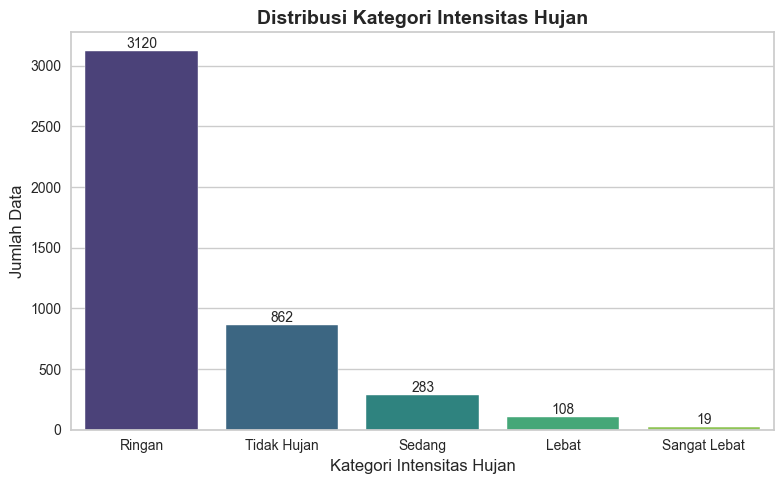

In [48]:
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

sns.countplot(
    data=data,
    x='intensitas_hujan',
    order=data['intensitas_hujan'].value_counts().index,
    palette="viridis"
)

plt.title("Distribusi Kategori Intensitas Hujan", fontsize=14, fontweight='bold')
plt.xlabel("Kategori Intensitas Hujan", fontsize=12)
plt.ylabel("Jumlah Data", fontsize=12)

for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()


VISUALISASI PETA FORECASTING INTENSITAS HUJAN 7 HARI KE DEPAN DI STASIUN BMKG SELURUH JAWA TIMUR TAHUN 2024 MENGGUNAKAN EXPONENSIAL SMOOTHING

In [49]:
data['tanggal'] = pd.to_datetime(data['tanggal'], errors='coerce').dt.date
tanggal_unik = sorted(data['tanggal'].dropna().unique())

display(HTML("""
<style>
.jp-Widget[df-widget="DatePicker"] input, 
.jp-Widget[df-widget="Dropdown"] select {
    width: fit-content !important;
    min-width: 150px;
    padding: 3px 8px;
}
</style>
"""))

COLOR_MAP = {
    "Tidak Hujan": "green",
    "Ringan": "blue",
    "Sedang": "orange",
    "Lebat": "red",
    "Sangat Lebat": "maroon"
}

date_picker = widgets.DatePicker(
    description='Pilih Tanggal:',
    disabled=False,
    value=tanggal_unik[0] if tanggal_unik else None,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='fit-content', min_width='150px')
)

data_option = widgets.Dropdown(
    options=['Aktual'] + [f'Forecast H+{i}' for i in range(1, 8)],
    description='Pilih Jenis Data:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='fit-content', min_width='180px')
)

output = widgets.Output()

def tampilkan_peta(change=None):
    with output:
        clear_output(wait=True)
        tanggal_input = date_picker.value
        if not tanggal_input:
            print("Silakan pilih tanggal terlebih dahulu.")
            return
        if tanggal_input not in tanggal_unik:
            print(f"Data untuk tanggal {tanggal_input.strftime('%Y/%m/%d')} tidak ditemukan.")
            return

        data_filter = data[data['tanggal'] == tanggal_input]
        if data_filter.empty:
            print(f"Tidak ada data untuk tanggal {tanggal_input.strftime('%Y/%m/%d')}.")
            return

        kolom_map = {'Aktual': ('intensitas_hujan', 'Aktual')}
        for i in range(1, 8):
            kolom_map[f'Forecast H+{i}'] = (f'intensitas_forecast_{i}', f'Forecast H+{i}')

        kolom, judul = kolom_map[data_option.value]
        lat_center = data_filter['latitude'].mean()
        lon_center = data_filter['longitude'].mean()
        lat_range = data_filter['latitude'].max() - data_filter['latitude'].min()
        lon_range = data_filter['longitude'].max() - data_filter['longitude'].min()
        zoom_level = 7 if max(lat_range, lon_range) > 0.4 else 8 if max(lat_range, lon_range) > 0.2 else 10

        fig = px.scatter_mapbox(
            data_filter,
            lat="latitude",
            lon="longitude",
            color=kolom,
            color_discrete_map=COLOR_MAP,
            hover_name="stasiun",
            hover_data={col: True for col in data_filter.columns},
            zoom=zoom_level,
            height=600,
            title=f"Peta {judul} Intensitas Curah Hujan -  Stasiun BMKG seluruh Jawa Timur ({tanggal_input})"
        )

        fig.update_layout(
            mapbox_style="open-street-map",
            mapbox_center={"lat": lat_center, "lon": lon_center},
            showlegend=False,
            margin={"r": 0, "t": 50, "l": 0, "b": 0},
            title=dict(font=dict(size=20, color='black', family="Arial"), x=0.5)
        )

        fig.update_traces(marker=dict(size=18, opacity=0.9))
        fig.show()

        legend_html = """
        <div style="font-family: Arial; font-size: 14px; margin-top: 10px;">
            <b>Legenda Intensitas Hujan:</b><br>
            <span style='color:green;'>● Tidak Hujan</span> &nbsp;
            <span style='color:blue;'>● Ringan</span> &nbsp;
            <span style='color:orange;'>● Sedang</span> &nbsp;
            <span style='color:red;'>● Lebat</span> &nbsp;
            <span style='color:maroon;'>● Sangat Lebat</span>
        </div>
        """
        display(HTML(legend_html))

        html_table = data_filter.to_html(index=False, justify='center', border=1, classes='table table-striped')
        scrollable_table = f"""
        <div style="overflow-x: auto; border: 1px solid #ddd; border-radius: 5px; padding: 5px; margin-top: 5px;">
            {html_table}
        </div>
        """
        display(HTML("<h4 style='font-family: Arial;'>Data pada tanggal terpilih:</h4>"))
        display(HTML(scrollable_table))

date_picker.observe(tampilkan_peta, names='value')
data_option.observe(tampilkan_peta, names='value')

display(widgets.HBox([date_picker, data_option]))
display(output)


Output()